#House Price Pridiction

#Data Collection

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/drive/MyDrive/house_prices.csv')

In [5]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [6]:
print("Shape : ",df.shape)
df.info()
df.isnull().sum()

Shape :  (187531, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non

,0
Index,0
Title,0
Description,3023
Amount(in rupees),0
Price (in rupees),17665
location,0
Carpet Area,80673
Status,615
Floor,7077
Transaction,83


#Data Cleaning

In [7]:
# yauta clean copy original dataset ko for future use in case
df_raw = df.copy()

In [8]:
Cols_To_Drop = ['Dimensions', 'Plot Area', 'Society', 'Super Area','overlooking', 'facing', 'Car Parking', 'Description']
df = df.drop(columns=Cols_To_Drop)

In [9]:
print("New Shape: ", df.shape)
df.columns.to_list()

New Shape:  (187531, 13)


['Index',
 'Title',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'Bathroom',
 'Balcony',
 'Ownership']

Since our target column gives output in object (42 Lac)  lets conver the Lackh to numbers only.

In [10]:
def convert_amount(value):
    value = str(value).strip()          # To remove extra whitespace
    value = value.replace(',', '')       # To remove any commas like "1,200"

    if 'Lac' in value:
        number = float(value.replace('Lac', '').strip())
        return number * 100000
    elif 'Cr' in value:
        number = float(value.replace('Cr', '').strip())
        return number * 10000000
    else:
        return None   # unexpected format, mark as missing for now

In [11]:
# Apply it to every row
df['Amount_clean'] = df['Amount(in rupees)'].apply(convert_amount)
df[['Amount(in rupees)', 'Amount_clean']].head(10)

,Amount(in rupees),Amount_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [12]:
df['Amount_clean'].isnull().sum()

np.int64(9684)

In [13]:
df[df['Amount_clean'].isnull()]['Amount(in rupees)'].unique()[:20]

array(['Call for Price'], dtype=object)

In [14]:
df = df.dropna(subset=['Amount_clean'])
print("New Shape after droping null values : ",df.shape)

New Shape after droping null values :  (177847, 14)


In [15]:
# Drop the original messy text column, keep only the clean numeric one
df = df.drop(columns=['Amount(in rupees)'])

# Rename Amount_clean to something simpler — this is now our target
df = df.rename(columns={'Amount_clean': 'Price_Total'})

df[['Price_Total']].describe()

,Price_Total
count,1.778470e+05
mean,1.198134e+07
std,3.943827e+07
min,1.000000e+05
25%,4.840000e+06
50%,7.800000e+06
75%,1.450000e+07
max,1.400300e+10


In [16]:
def clean_area(value):
    if pd.isnull(value):
        return None
    value = str(value).lower().strip()
    value = value.replace('sqft', '').replace('sq.ft.', '').replace(',', '').strip()
    try:
        return float(value)
    except:
        return None

In [17]:
df['Carpet_Area_clean'] = df['Carpet Area'].apply(clean_area)

df[['Carpet Area', 'Carpet_Area_clean']].head(10)
print("Nulls in Carpet_Area_clean:", df['Carpet_Area_clean'].isnull().sum())

Nulls in Carpet_Area_clean: 81861


In [18]:
df[['Carpet Area', 'Carpet_Area_clean']].head(10)

,Carpet Area,Carpet_Area_clean
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [19]:
# Fill missing Carpet Area with the median area for that location
df['Carpet_Area_clean'] = df.groupby('location')['Carpet_Area_clean'].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining nulls:", df['Carpet_Area_clean'].isnull().sum())

Remaining nulls: 0


In [20]:
df = df.drop(columns=['Carpet Area'])
df = df.rename(columns={'Carpet_Area_clean': 'Carpet_Area'})

df[['Carpet_Area']].describe()

,Carpet_Area
count,177847.000000
mean,1181.928062
std,2356.444026
min,1.000000
25%,900.000000
50%,1010.000000
75%,1300.000000
max,709222.000000


In [21]:
df.isnull().sum().sort_values(ascending=False)

,0
Ownership,61925
Balcony,47159
Price (in rupees),7981
Floor,6949
Furnishing,2067
Bathroom,760
Status,595
Transaction,67
Index,0
location,0


In [22]:
df['Ownership'] = df['Ownership'].fillna('Unknown')
df['Furnishing'] = df['Furnishing'].fillna('Unknown')

# Status and Transaction: fill with the most common value (the "mode")
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])
df['Transaction'] = df['Transaction'].fillna(df['Transaction'].mode()[0])

df[['Ownership', 'Furnishing', 'Status', 'Transaction']].isnull().sum()

,0
Ownership,0
Furnishing,0
Status,0
Transaction,0


In [23]:
print(df['Balcony'].unique()[:15])
print(df['Bathroom'].unique()[:15])

['2' nan '1' '3' '4' '6' '5' '7' '> 10' '10' '8' '9']
['1' '2' '3' '4' '6' nan '5' '9' '8' '> 10' '7' '10']


In [24]:
print(df['Floor'].unique()[:15])

['10 out of 11' '3 out of 22' '10 out of 29' '1 out of 3' '20 out of 42'
 '2 out of 7' '4 out of 5' 'Ground out of 7' 'Ground out of 2'
 '3 out of 27' '6 out of 20' '16 out of 24' '8 out of 20' '18 out of 27'
 '2 out of 3']


In [25]:
def clean_count(value):
    if pd.isnull(value):
        return None
    value = str(value).strip()
    if value == '> 10':
        return 11
    try:
        return float(value)
    except:
        return None

df['Balcony'] = df['Balcony'].apply(clean_count)
df['Bathroom'] = df['Bathroom'].apply(clean_count)

# Now fill missing values with the median (a typical/middle value)
df['Balcony'] = df['Balcony'].fillna(df['Balcony'].median())
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())

print(df['Balcony'].isnull().sum(), df['Bathroom'].isnull().sum())

0 0


In [26]:
def split_floor(value):
    if pd.isnull(value):
        return pd.Series([None, None])
    value = str(value).strip()
    parts = value.split(' out of ')
    if len(parts) != 2:
        return pd.Series([None, None])

    floor_part, total_part = parts

    # Handle "Ground" as floor 0
    floor_part = floor_part.replace('Ground', '0').replace('Lower Basement', '-1').replace('Upper Basement', '-1')

    try:
        floor_num = float(floor_part)
    except:
        floor_num = None
    try:
        total_num = float(total_part)
    except:
        total_num = None

    return pd.Series([floor_num, total_num])

df[['Floor_Number', 'Total_Floors']] = df['Floor'].apply(split_floor)

print(df[['Floor', 'Floor_Number', 'Total_Floors']].head(10))
print("Nulls:", df['Floor_Number'].isnull().sum(), df['Total_Floors'].isnull().sum())

             Floor  Floor_Number  Total_Floors
0     10 out of 11          10.0          11.0
1      3 out of 22           3.0          22.0
2     10 out of 29          10.0          29.0
3       1 out of 3           1.0           3.0
4     20 out of 42          20.0          42.0
5       2 out of 7           2.0           7.0
6       4 out of 5           4.0           5.0
7  Ground out of 7           0.0           7.0
8  Ground out of 2           0.0           2.0
9      3 out of 27           3.0          27.0
Nulls: 6995 6995


In [27]:
df['Floor_Number'] = df['Floor_Number'].fillna(df['Floor_Number'].median())
df['Total_Floors'] = df['Total_Floors'].fillna(df['Total_Floors'].median())

# Drop the original messy text column
df = df.drop(columns=['Floor'])

print(df.isnull().sum().sort_values(ascending=False))

Price (in rupees)    7981
Index                   0
Title                   0
location                0
Status                  0
Transaction             0
Furnishing              0
Bathroom                0
Balcony                 0
Ownership               0
Price_Total             0
Carpet_Area             0
Floor_Number            0
Total_Floors            0
dtype: int64


In [28]:
df['Price (in rupees)'] = df['Price (in rupees)'].fillna(df['Price_Total'] / df['Carpet_Area'])

# Rename for clarity
df = df.rename(columns={'Price (in rupees)': 'Price_per_sqft'})

print("Remaining nulls:", df['Price_per_sqft'].isnull().sum())
df.isnull().sum().sort_values(ascending=False)

Remaining nulls: 0


,0
Index,0
Title,0
Price_per_sqft,0
location,0
Status,0
Transaction,0
Furnishing,0
Bathroom,0
Balcony,0
Ownership,0


# EDA (Exploratory Data Analysis)

In [29]:
# Trget Distribution

import matplotlib.pyplot as plt
import seaborn as sns

df['Price_Total'].describe()

,Price_Total
count,1.778470e+05
mean,1.198134e+07
std,3.943827e+07
min,1.000000e+05
25%,4.840000e+06
50%,7.800000e+06
75%,1.450000e+07
max,1.400300e+10


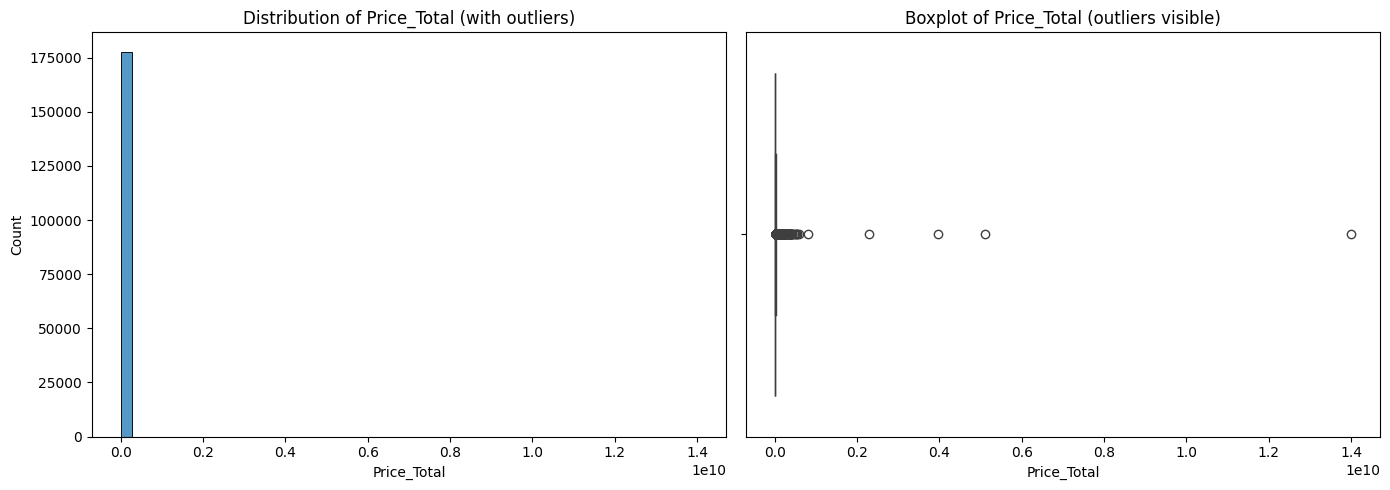

In [30]:
# Outlier Detection

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows the shape of the distribution
sns.histplot(df['Price_Total'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Price_Total (with outliers)')

# Boxplot - shows outliers as individual dots beyond the "whiskers"
sns.boxplot(x=df['Price_Total'], ax=axes[1])
axes[1].set_title('Boxplot of Price_Total (outliers visible)')

plt.tight_layout()
plt.show()

In [31]:
# Outlier  Handeling

Q1 = df['Price_Total'].quantile(0.25)
Q3 = df['Price_Total'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:,.0f}")
print(f"Upper bound: {upper_bound:,.0f}")

outliers = df[(df['Price_Total'] < lower_bound) | (df['Price_Total'] > upper_bound)]
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")

Lower bound: -9,650,000
Upper bound: 28,990,000
Number of outliers: 12283 (6.91% of data)


In [32]:
df_clean = df[(df['Price_Total'] >= lower_bound) & (df['Price_Total'] <= upper_bound)]

# Since lower_bound is negative (meaningless), this naturally only filters the expensive end
print("Shape before removing outliers:", df.shape)
print("Shape after removing outliers:", df_clean.shape)

df = df_clean.copy()

Shape before removing outliers: (177847, 14)
Shape after removing outliers: (165564, 14)


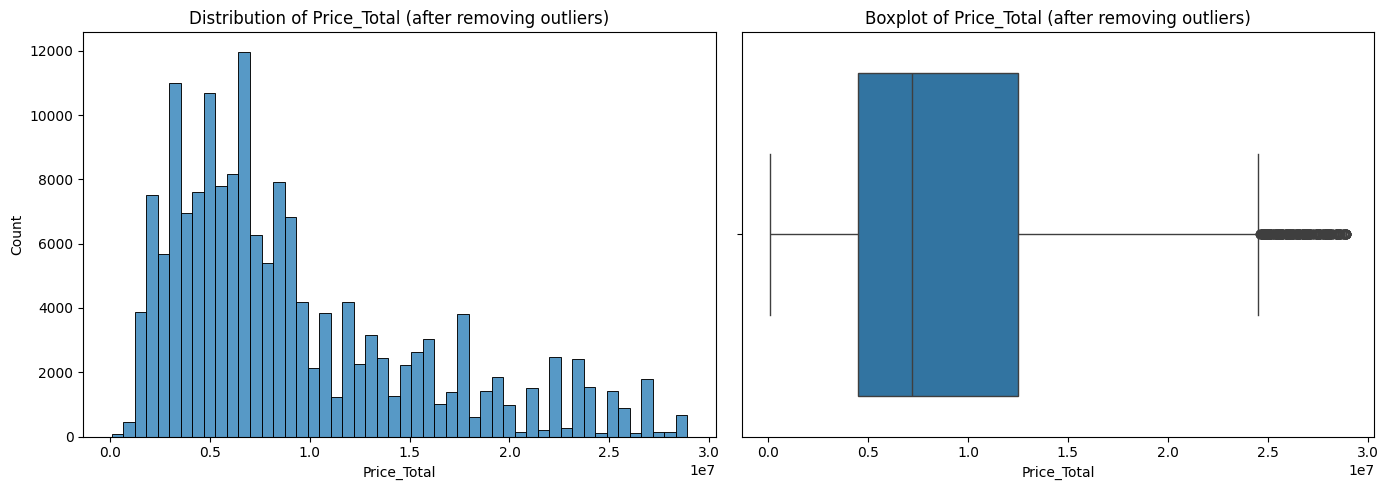

,Price_Total
count,1.655640e+05
mean,9.185406e+06
std,6.320746e+06
min,1.000000e+05
25%,4.500000e+06
50%,7.200000e+06
75%,1.250000e+07
max,2.890000e+07


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price_Total'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Price_Total (after removing outliers)')

sns.boxplot(x=df['Price_Total'], ax=axes[1])
axes[1].set_title('Boxplot of Price_Total (after removing outliers)')

plt.tight_layout()
plt.show()

df['Price_Total'].describe()

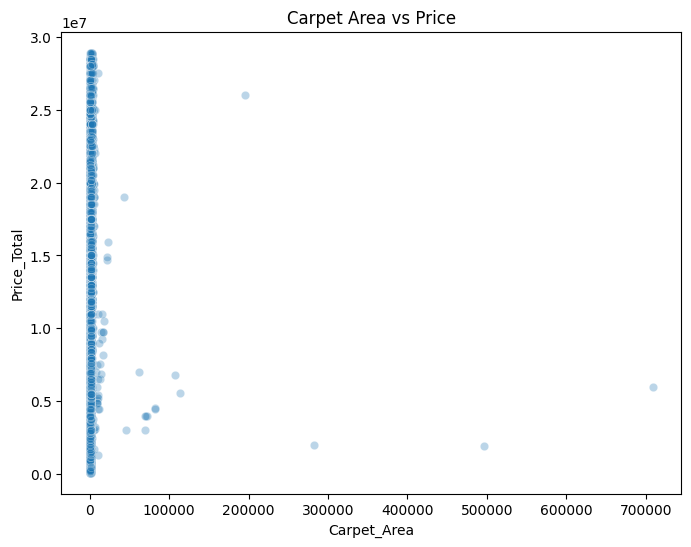

Correlation: 0.08328923063735579


In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Carpet_Area', y='Price_Total', data=df, alpha=0.3)
plt.title('Carpet Area vs Price')
plt.show()

# Correlation - a number between -1 and 1 measuring the strength of linear relationship
print("Correlation:", df['Carpet_Area'].corr(df['Price_Total']))

In [35]:
df['Carpet_Area'].describe()

,Carpet_Area
count,165564.000000
mean,1103.274320
std,2401.780902
min,1.000000
25%,880.000000
50%,1000.000000
75%,1300.000000
max,709222.000000


In [36]:
Q1_area = df['Carpet_Area'].quantile(0.25)
Q3_area = df['Carpet_Area'].quantile(0.75)
IQR_area = Q3_area - Q1_area

lower_area = Q1_area - 1.5 * IQR_area
upper_area = Q3_area + 1.5 * IQR_area

print(f"Lower bound: {lower_area:,.0f}, Upper bound: {upper_area:,.0f}")

df = df[(df['Carpet_Area'] >= lower_area) & (df['Carpet_Area'] <= upper_area)]

print("New shape:", df.shape)
df['Carpet_Area'].describe()

Lower bound: 250, Upper bound: 1,930
New shape: (159988, 14)


,Carpet_Area
count,159988.000000
mean,1063.853361
std,312.818522
min,250.000000
25%,880.000000
50%,1000.000000
75%,1296.000000
max,1930.000000


Correlation: 0.5115967200204866


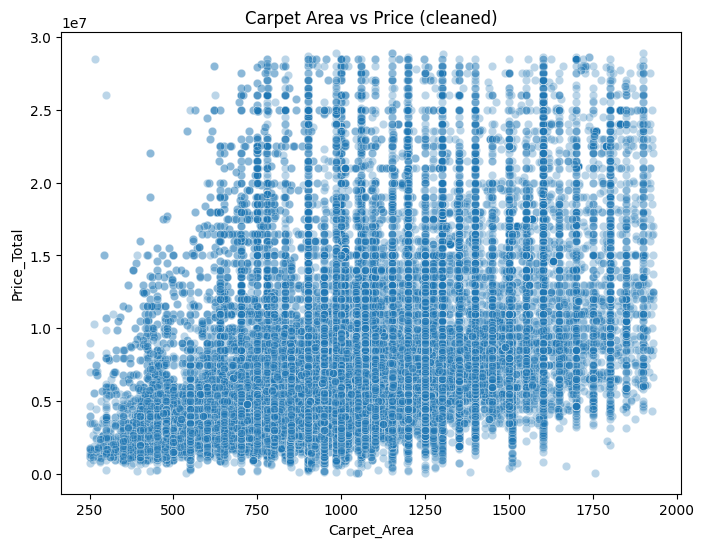

In [37]:
# Categorical Breakdown
print("Correlation:", df['Carpet_Area'].corr(df['Price_Total']))

plt.figure(figsize=(8,6))
sns.scatterplot(x='Carpet_Area', y='Price_Total', data=df, alpha=0.3)
plt.title('Carpet Area vs Price (cleaned)')
plt.show()

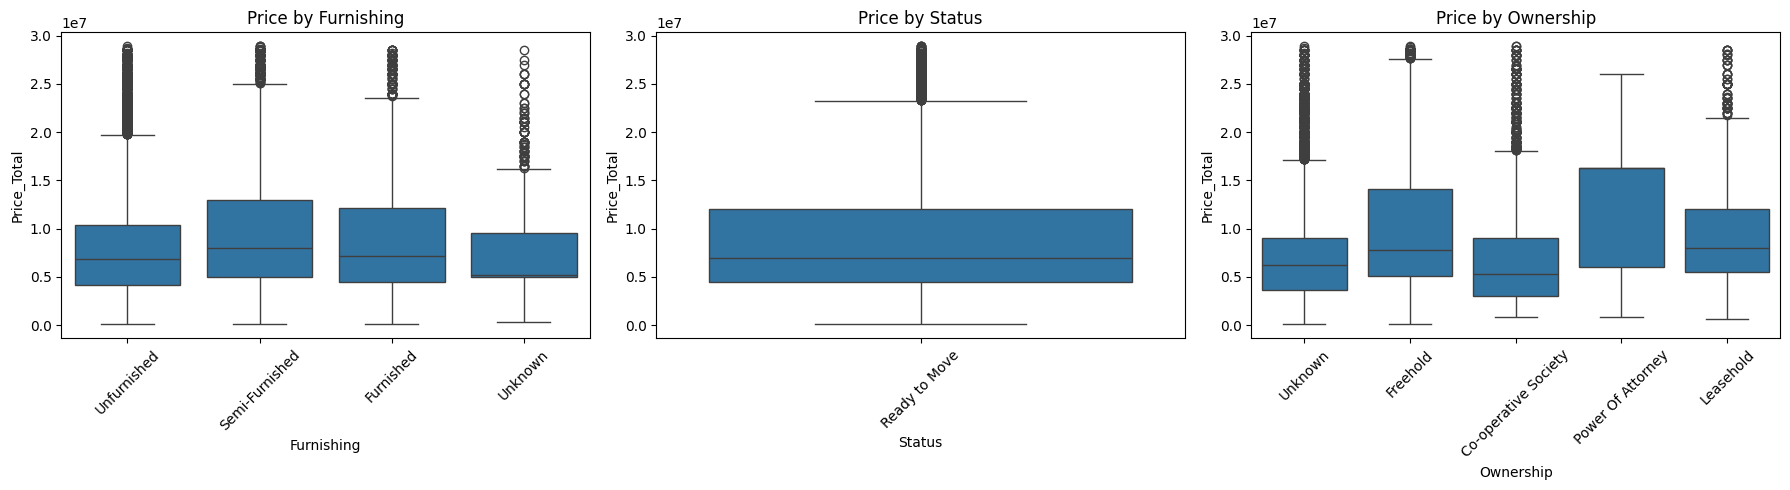

In [38]:
# Relationships

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Furnishing', y='Price_Total', data=df, ax=axes[0])
axes[0].set_title('Price by Furnishing')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Status', y='Price_Total', data=df, ax=axes[1])
axes[1].set_title('Price by Status')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x='Ownership', y='Price_Total', data=df, ax=axes[2])
axes[2].set_title('Price by Ownership')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


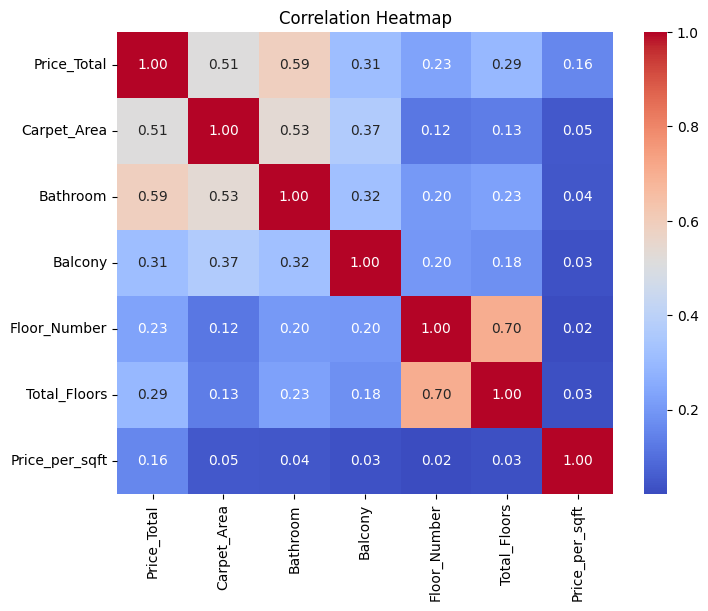

In [39]:
numeric_cols = ['Price_Total', 'Carpet_Area', 'Bathroom', 'Balcony', 'Floor_Number', 'Total_Floors', 'Price_per_sqft']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [40]:
df = df.drop(columns=['Status', 'Price_per_sqft', 'Title'])

print(df.shape)
df.columns.tolist()

(159988, 11)


['Index',
 'location',
 'Transaction',
 'Furnishing',
 'Bathroom',
 'Balcony',
 'Ownership',
 'Price_Total',
 'Carpet_Area',
 'Floor_Number',
 'Total_Floors']

#Feature Engineering

In [41]:
print("Unique locations:", df['location'].nunique())
df['location'].value_counts().head(10)

Unique locations: 81


,count
location,
bangalore,22242
new-delhi,20879
kolkata,20789
gurgaon,14812
ahmedabad,11317
chennai,8941
hyderabad,8903
jaipur,7779
greater-noida,4333


In [42]:
# Calculate average price per location
location_price_map = df.groupby('location')['Price_Total'].mean()

# Create a new numeric column based on this mapping
df['location_encoded'] = df['location'].map(location_price_map)

df[['location', 'location_encoded']].head(10)

,location,location_encoded
0,thane,8.604028e+06
1,thane,8.604028e+06
2,thane,8.604028e+06
3,thane,8.604028e+06
4,thane,8.604028e+06
5,thane,8.604028e+06
6,thane,8.604028e+06
7,thane,8.604028e+06
8,thane,8.604028e+06
9,thane,8.604028e+06


Why this is powerful? - instead of treating "bangalore" as just an arbitrary label, we're now telling the model exactly how expensive that location tends to be  directly useful numeric information, in a single column

In [43]:
df['location_encoded'].isnull().sum()

np.int64(0)

In [44]:
print(df['Furnishing'].nunique(), df['Ownership'].nunique(), df['Transaction'].nunique())

df = pd.get_dummies(df, columns=['Furnishing', 'Ownership', 'Transaction'], drop_first=True)

print(df.shape)
df.head()

4 5 4
(159988, 19)


,Index,location,Bathroom,Balcony,Price_Total,Carpet_Area,Floor_Number,Total_Floors,location_encoded,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Furnishing_Unknown,Ownership_Freehold,Ownership_Leasehold,Ownership_Power Of Attorney,Ownership_Unknown,Transaction_Other,Transaction_Rent/Lease,Transaction_Resale
0,0,thane,1.0,2.0,4200000.0,500.0,10.0,11.0,8.604028e+06,False,True,False,False,False,False,True,False,False,True
1,1,thane,2.0,2.0,9800000.0,473.0,3.0,22.0,8.604028e+06,True,False,False,True,False,False,False,False,False,True
2,2,thane,2.0,2.0,14000000.0,779.0,10.0,29.0,8.604028e+06,False,True,False,True,False,False,False,False,False,True
3,3,thane,1.0,1.0,2500000.0,530.0,1.0,3.0,8.604028e+06,False,True,False,False,False,False,True,False,False,True
4,4,thane,2.0,2.0,16000000.0,635.0,20.0,42.0,8.604028e+06,False,True,False,False,False,False,False,False,False,True


In [45]:
df = df.drop(columns=['Index', 'location'])

print(df.shape)
df.columns.tolist()

(159988, 17)


['Bathroom',
 'Balcony',
 'Price_Total',
 'Carpet_Area',
 'Floor_Number',
 'Total_Floors',
 'location_encoded',
 'Furnishing_Semi-Furnished',
 'Furnishing_Unfurnished',
 'Furnishing_Unknown',
 'Ownership_Freehold',
 'Ownership_Leasehold',
 'Ownership_Power Of Attorney',
 'Ownership_Unknown',
 'Transaction_Other',
 'Transaction_Rent/Lease',
 'Transaction_Resale']

 core ML concept: we split our dataframe into:

X = all the input features (everything the model gets to see)

y = the target (what the model is trying to predict)

In [46]:
X = df.drop(columns=['Price_Total'])
y = df['Price_Total']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (159988, 16)
y shape: (159988,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (127990, 16)
Test size: (31998, 16)


#Machine Learning

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [51]:
y_pred = model.predict(X_test)

# Compare a few real vs predicted prices
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
87355,3500000.0,3.985609e+06
165231,7000000.0,9.624375e+06
47454,7500000.0,6.722160e+06
172039,8000000.0,1.166701e+07
66719,8500000.0,1.249940e+07
38977,8800000.0,8.784725e+06
136129,23500000.0,2.020409e+07
104532,1830000.0,2.063421e+06
108123,12100000.0,1.437856e+07
75383,9300000.0,1.062218e+07


Model Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): ₹{mae:,.0f}")
print(f"RMSE (Root Mean Squared Error): ₹{rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

MAE  (Mean Absolute Error): ₹3,007,267
RMSE (Root Mean Squared Error): ₹4,094,832
R² Score: 0.5309


#Visualizaaation

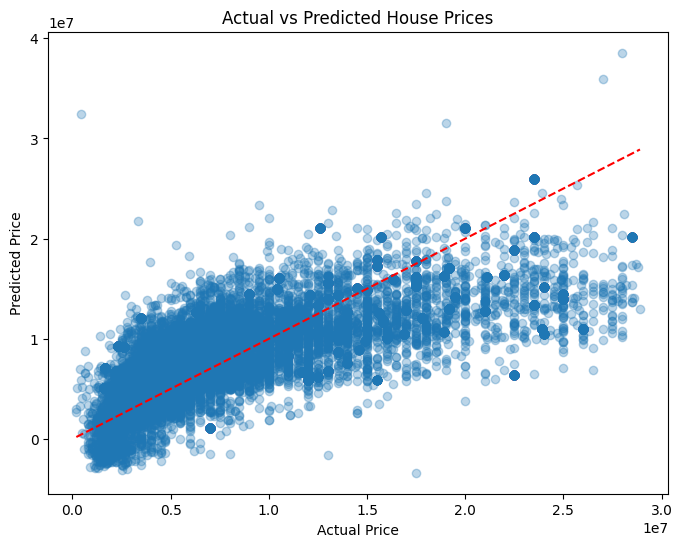

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

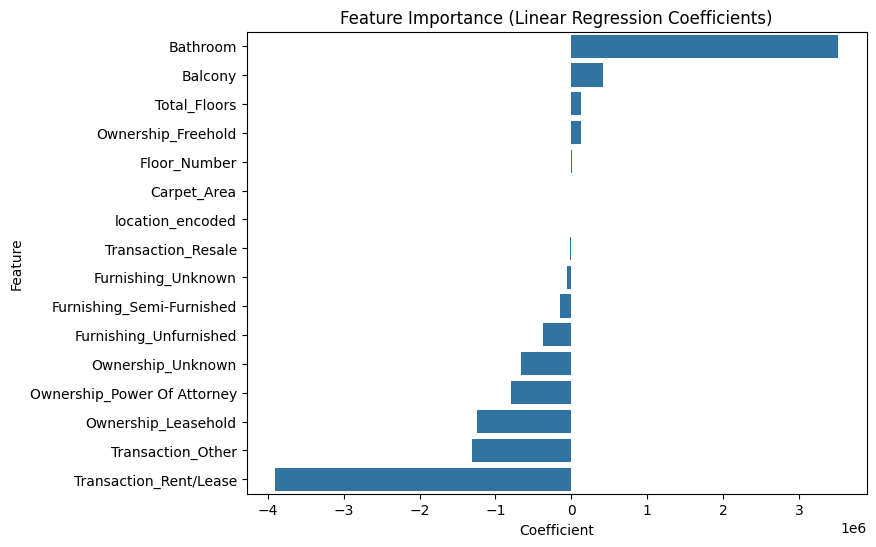

In [54]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()

In [55]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print(f"MAPE (average error): {mape:.2f}%")
print(f"Approximate Accuracy: {accuracy:.2f}%")

MAPE (average error): 46.77%
Approximate Accuracy: 53.23%


 House Price Prediction (Level 0)
Stage 1 — Business Problem

Predict total house price (Price_Total) in India using structured features — a regression problem.
Stage 2 — Data Collection

Pre-existing scraped real estate dataset (187,531 listings).
Stage 3 — Data Cleaning

Converted Amount(in rupees) text ("42 Lac"/"1.40 Cr") → real numeric rupees
Dropped 8 mostly-empty columns (Dimensions, Plot Area, Society, etc.)
Smart-filled Carpet_Area using location-grouped medians
Split Floor ("10 out of 11") into two clean numeric columns
Derived missing Price_per_sqft mathematically instead of guessing
Result: zero missing values across the dataset

Stage 4 — EDA

Found and removed outliers in Price_Total and Carpet_Area using the IQR method
Discovered outliers were masking a real relationship — correlation jumped from 0.08 → 0.51 after cleaning
Found Bathroom (0.59) was actually the strongest numeric predictor, beating Carpet_Area (0.51)
Identified Status as a useless dead column (zero variation) and Price_per_sqft as a leaky one

Stage 5 — Feature Engineering

Target-encoded location (81 cities) by average price
One-hot encoded Furnishing, Ownership, Transaction
Learned about (and consciously accepted, for this scope) a minor data leakage tradeoff
Train/test split: 80/20

Stage 6 — Machine Learning

Trained a Linear Regression model on 127,990 rows.
Stage 7 — Model Evaluation

MAE ≈ ₹30L, RMSE ≈ ₹41L, R² ≈ 0.53 — explains about half the price variation; a solid, honest baseline

Stage 8 — Visualization

Predicted vs actual scatter plot + feature coefficient chart to interpret the model's behavior.



In [56]:
import pickle

# Save the trained model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save the location_price_map - we'll need it to encode new user inputs later
with open('location_price_map.pkl', 'wb') as f:
    pickle.dump(location_price_map, f)

# Also save the exact list/order of columns the model expects
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

In [57]:
from google.colab import files

files.download('house_price_model.pkl')
files.download('location_price_map.pkl')
files.download('model_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>